In [1]:
import math
from pathlib import Path

import matplotlib.pyplot as plt

PAPER_FIGSIZE = (6, 4)


import torch

from model import PFNRegressor, RiemannDistribution
from utility import Random_Kraus as kraus

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64)

CHECKPOINT1 = Path(
    "runs/unitarity3d/512e_8h_1024ff_16l_1024dec_5M_p80_lr3e-5_min1e-6_from10M_20260522_171836/model_weights.pt"
)

CHECKPOINT2 = Path(
    "jobs/unitarity3d/unitarity3d_resume_153135_20260528_145042/model_weights.pt"
)


SEED = 22
BUDGET = 50
r_dec = 2
d_env = 2

In [2]:
def normalize_unitarity3d_x(x, device=DEVICE):
    scale = torch.tensor([2 * math.pi, math.pi, 2 * math.pi], device=device, dtype=x.dtype)
    return x / scale


def choi_su2_3d(alpha, beta, gamma):
    alpha = torch.as_tensor(alpha, dtype=torch.float64, device=alpha.device)
    beta = torch.as_tensor(beta, dtype=torch.float64, device=beta.device)
    gamma = torch.as_tensor(gamma, dtype=torch.float64, device=gamma.device)

    original_shape = alpha.shape
    a = alpha.reshape(-1) / 2
    b = beta.reshape(-1) / 2
    g = gamma.reshape(-1) / 2
    zeros = torch.zeros_like(a, dtype=torch.complex128)

    rz_alpha = torch.stack(
        [
            torch.stack([torch.exp(-1j * a), zeros], dim=-1),
            torch.stack([zeros, torch.exp(1j * a)], dim=-1),
        ],
        dim=-2,
    )
    ry_beta = torch.stack(
        [
            torch.stack([torch.cos(b), -torch.sin(b)], dim=-1),
            torch.stack([torch.sin(b), torch.cos(b)], dim=-1),
        ],
        dim=-2,
    ).to(torch.complex128)
    rz_gamma = torch.stack(
        [
            torch.stack([torch.exp(-1j * g), zeros], dim=-1),
            torch.stack([zeros, torch.exp(1j * g)], dim=-1),
        ],
        dim=-2,
    )

    unitary = rz_alpha @ ry_beta @ rz_gamma
    vec_unitary = unitary.reshape(-1, 4, 1)
    choi = vec_unitary @ vec_unitary.mH
    return choi.reshape(*original_shape, 4, 4)


@torch.no_grad()
def unitarity3d_from_comb(alpha, beta, gamma, comb):
    j_in = choi_su2_3d(alpha, beta, gamma).to(comb.device)
    j_out = torch.einsum("maoi,mnij,mapj->mnop", comb, j_in, comb.conj())
    return (j_out @ j_out).diagonal(dim1=-2, dim2=-1).sum(-1).real.div(4).unsqueeze(-1)


def make_unitarity3d_model(payload, device=DEVICE):
    cfg = payload["transformer"]
    hp = payload["hyperparameters"]
    model = PFNRegressor(
        x_dim=3,
        y_dim=1,
        emb_size=cfg["emb_size"],
        n_heads=cfg["n_heads"],
        ff_hidden=cfg["ff_hidden"],
        n_layers=cfg["n_layers"],
        num_buckets=hp["num_buckets"],
        dropout=cfg["dropout"],
        use_x_norm=False,
        decoder_hidden=cfg.get("decoder_hidden", 1024),
    ).to(device)
    model.load_state_dict(payload["model_state_dict"])
    model.eval()
    return model


def make_unitarity3d_dist(payload, device=DEVICE):
    hp = payload["hyperparameters"]
    boundaries = torch.linspace(0.25, 1.0, hp["num_buckets"] + 1, device=device, dtype=torch.float64)
    return RiemannDistribution(boundaries, use_tails=False).to(device)


def make_angle_slice(vary_angle, grid, fixed_alpha=0.0, fixed_beta=0.0, fixed_gamma=0.0, device=DEVICE):
    alpha = torch.full((1, grid.numel()), fixed_alpha, device=device, dtype=torch.float64)
    beta = torch.full((1, grid.numel()), fixed_beta, device=device, dtype=torch.float64)
    gamma = torch.full((1, grid.numel()), fixed_gamma, device=device, dtype=torch.float64)
    if vary_angle == "alpha":
        alpha = grid.view(1, -1) * 2 * math.pi
    elif vary_angle == "beta":
        beta = grid.view(1, -1) * math.pi
    elif vary_angle == "gamma":
        gamma = grid.view(1, -1) * 2 * math.pi
    else:
        raise ValueError("vary_angle must be one of: alpha, beta, gamma")
    return alpha, beta, gamma


@torch.no_grad()
def plot_unitarity3d_prediction(
    checkpoint_path,
    vary_angle="beta",
    context_points=12,
    task_points=None,
    grid_points=1000,
    fixed_alpha=0.0,
    fixed_beta=0.0,
    fixed_gamma=0.0,
    seed=32,
    d_env=2,
    r_dec=2
):
    payload = torch.load(checkpoint_path, map_location=DEVICE)
    model = make_unitarity3d_model(payload, DEVICE)
    dist = make_unitarity3d_dist(payload, DEVICE)
    hp = payload["hyperparameters"]

    task_points = task_points or max(hp["max_num_points"], context_points + 8)
    torch.manual_seed(seed)
    if DEVICE.type == "cuda":
        torch.cuda.manual_seed_all(seed)

    comb = kraus.generate_one_slot_kraus_comb(
        num_samples=1,
        sys_dim=(2, 2, 2, 2),
        env_dim=d_env,
        r_enc=1,
        r_dec=r_dec,
    ).to(DEVICE)

    random_grid = torch.rand(1, task_points, device=DEVICE, dtype=torch.float64)
    alpha, beta, gamma = make_angle_slice(
        vary_angle,
        random_grid.flatten(),
        fixed_alpha=fixed_alpha,
        fixed_beta=fixed_beta,
        fixed_gamma=fixed_gamma,
        device=DEVICE,
    )
    x_all = normalize_unitarity3d_x(torch.stack([alpha, beta, gamma], dim=-1), DEVICE)[0]
    y_all = unitarity3d_from_comb(alpha, beta, gamma, comb)[0]

    angle_col = {"alpha": 0, "beta": 1, "gamma": 2}[vary_angle]
    context_points = min(context_points, task_points - 1)
    ctx_idx = torch.randperm(task_points, device=DEVICE)[:context_points]
    ctx_idx = ctx_idx[torch.argsort(x_all[ctx_idx, angle_col])]
    x_ctx = x_all[ctx_idx]
    y_ctx = y_all[ctx_idx]

    grid = torch.linspace(0, 1, grid_points, device=DEVICE, dtype=torch.float64)
    alpha_g, beta_g, gamma_g = make_angle_slice(
        vary_angle,
        grid,
        fixed_alpha=fixed_alpha,
        fixed_beta=fixed_beta,
        fixed_gamma=fixed_gamma,
        device=DEVICE,
    )
    x_grid = normalize_unitarity3d_x(torch.stack([alpha_g, beta_g, gamma_g], dim=-1), DEVICE)[0]
    y_true = unitarity3d_from_comb(alpha_g, beta_g, gamma_g, comb)[0, :, 0]

    logits = model(x_ctx.unsqueeze(0), y_ctx.unsqueeze(0), x_grid.unsqueeze(0))
    mean = dist.mean(logits)[0]
    lower = dist.quantile(logits, 0.025)[0]
    upper = dist.quantile(logits, 0.975)[0]

    fig, ax = plt.subplots(figsize=PAPER_FIGSIZE)
    ax.plot(grid.cpu(), y_true.cpu(), color="tab:green", linewidth=2, label="true")
    ax.fill_between(
        grid.cpu(),
        lower.detach().cpu(),
        upper.detach().cpu(),
        color="tab:blue",
        alpha=0.2,
        label="PFN 95% interval",
    )
    ax.plot(grid.cpu(), mean.detach().cpu(), color="tab:blue", linewidth=2, label="PFN mean")
    ax.scatter(x_ctx[:, angle_col].cpu(), y_ctx[:, 0].cpu(), color="black", s=35, label=f"context ({context_points})")
    angle_label = {
    "alpha": r"$\alpha / 2\pi$",
    "beta": r"$\beta / \pi$",
    "gamma": r"$\gamma / 2\pi$",
    }[vary_angle]

    ax.set_xlabel(angle_label)
    ax.set_xlabel(f"normalized {vary_angle}")
    ax.set_ylabel("unitarity")
    ax.legend()
    ax.set_ylim(0.245, 1.05)
    fig.tight_layout()

    print("loaded:", checkpoint_path)
    print("step:", payload.get("step"), "seen_train_datasets:", payload.get("seen_train_datasets"))
    print("parameters:", payload.get("total_parameters"))
    return fig, ax, {"model": model, "dist": dist, "payload": payload}


loaded: runs/unitarity3d/512e_8h_1024ff_16l_1024dec_5M_p80_lr3e-5_min1e-6_from10M_20260522_171836/model_weights.pt
step: None seen_train_datasets: None
parameters: None


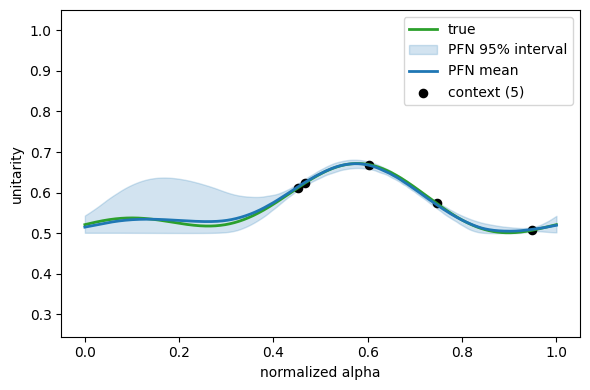

In [3]:
fig, ax, unitarity3d = plot_unitarity3d_prediction(checkpoint_path=CHECKPOINT1,
                                                           context_points=5,
                                                           vary_angle="alpha",
                                                           seed=SEED,
                                                           r_dec=r_dec,
                                                           d_env=d_env
)
plt.show()

In [4]:
def log_expected_improvement_from_logits(logits, dist, best_y, xi=0.0):
    """Log expected improvement for maximising y from bucket logits."""
    if dist.use_tails:
        raise ValueError("This notebook LogEI helper assumes use_tails=False.")

    log_probs = torch.log_softmax(logits, dim=-1)
    threshold = torch.as_tensor(best_y, device=logits.device, dtype=logits.dtype) + xi
    threshold = threshold.unsqueeze(-1)

    boundaries = dist.boundaries.to(device=logits.device, dtype=logits.dtype)
    widths = dist.widths.to(device=logits.device, dtype=logits.dtype)
    left = boundaries[:-1]
    right = boundaries[1:]

    bucket_ei = torch.zeros_like(logits)
    bucket_ei = torch.where(threshold <= left, (left + right) / 2 - threshold, bucket_ei)
    bucket_ei = torch.where(
        (left < threshold) & (threshold < right),
        (right - threshold).pow(2) / (2 * widths),
        bucket_ei,
    ).clamp_min(0.0)

    log_bucket_ei = torch.where(
        bucket_ei > 0,
        bucket_ei.log(),
        torch.full_like(bucket_ei, float("-inf")),
    )
    return torch.logsumexp(log_probs + log_bucket_ei, dim=-1)


@torch.no_grad()
def find_max_with_ei(model, dist, x_context, y_context, x_candidates, batch_size=4096, xi=0.0):
    """Return the candidate with the largest log expected improvement."""
    model.eval()

    if x_context.ndim == 2:
        x_context = x_context.unsqueeze(0)
    if y_context.ndim == 2:
        y_context = y_context.unsqueeze(0)
    if x_candidates.ndim == 2:
        x_candidates = x_candidates.unsqueeze(0)

    best_y = y_context.max(dim=1).values.squeeze(-1)
    log_ei_chunks = []

    for start in range(0, x_candidates.shape[1], batch_size):
        x_batch = x_candidates[:, start:start + batch_size]
        logits = model(x_context, y_context, x_batch)
        log_ei_chunks.append(log_expected_improvement_from_logits(logits, dist, best_y, xi=xi))

    log_ei = torch.cat(log_ei_chunks, dim=1)
    best_idx = log_ei.argmax(dim=1)
    best_x = x_candidates[torch.arange(x_candidates.shape[0], device=x_candidates.device), best_idx]
    best_log_ei = log_ei[torch.arange(log_ei.shape[0], device=log_ei.device), best_idx]
    return best_x, best_log_ei, best_idx, log_ei


def best_so_far_trace(result, max_evals=None):
    y_hist = result["y_history"][:, 0].detach().cpu()
    if max_evals is not None:
        y_hist = y_hist[:max_evals]
    return torch.cummax(y_hist, dim=0).values


def plot_best_so_far_comparison(approaches, max_evals=None, figsize=PAPER_FIGSIZE):
    fig, ax = plt.subplots(figsize=figsize)
    for label, result in approaches:
        best_so_far = best_so_far_trace(result, max_evals=max_evals)
        evals = torch.arange(1, len(best_so_far) + 1)
        ax.plot(evals, best_so_far, linewidth=1.8, label=label)
    ax.set_xlabel("evaluation")
    ax.set_ylabel("best unitarity so far")
    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()
    return fig, ax


def evaluate_unitarity3d_x(x, comb):
    """Evaluate true unitarity at normalized 3D angles x = [alpha/2pi, beta/pi, gamma/2pi]."""
    x = x.to(device=comb.device, dtype=torch.float64)
    if x.ndim == 1:
        x = x.reshape(1, 1, 3)
    elif x.ndim == 2:
        x = x.unsqueeze(0)
    alpha = x[..., 0] * 2 * math.pi
    beta = x[..., 1] * math.pi
    gamma = x[..., 2] * 2 * math.pi
    return unitarity3d_from_comb(alpha, beta, gamma, comb)


def sample_haar_normalized_x(num_points, device=DEVICE):
    """Sample Haar-random SU(2) Euler angles in the model's normalized coordinates."""
    alpha = torch.rand(num_points, device=device, dtype=torch.float64)
    beta = torch.acos(1 - 2 * torch.rand(num_points, device=device, dtype=torch.float64)) / math.pi
    gamma = torch.rand(num_points, device=device, dtype=torch.float64)
    return torch.stack([alpha, beta, gamma], dim=-1)


@torch.no_grad()
def run_ei_search_unitarity3d(
    checkpoint_path,
    budget=50,
    initial_points=1,
    candidate_points=20000,
    xi=0.0,
    seed=22,
    r_dec=2,
    d_env=2,
):
    """Use PFN EI for a fixed evaluation budget and return the best observed point."""
    if not (1 <= initial_points <= budget):
        raise ValueError("initial_points must be in [1, budget].")

    payload = torch.load(checkpoint_path, map_location=DEVICE)
    model = make_unitarity3d_model(payload, DEVICE)
    dist = make_unitarity3d_dist(payload, DEVICE)

    torch.manual_seed(seed)
    if DEVICE.type == "cuda":
        torch.cuda.manual_seed_all(seed)

    comb = kraus.generate_one_slot_kraus_comb(
        num_samples=1,
        sys_dim=(2, 2, 2, 2),
        env_dim=d_env,
        r_enc=1,
        r_dec=r_dec,
    ).to(DEVICE)

    x_ctx = sample_haar_normalized_x(initial_points, DEVICE)
    y_ctx = evaluate_unitarity3d_x(x_ctx, comb).reshape(initial_points, 1)

    for step in range(initial_points, budget):
        x_candidates = sample_haar_normalized_x(candidate_points, DEVICE)
        next_x, next_log_ei, _, _ = find_max_with_ei(
            model,
            dist,
            x_ctx,
            y_ctx,
            x_candidates,
            xi=xi,
        )
        next_y = evaluate_unitarity3d_x(next_x.reshape(1, 3), comb).reshape(1, 1)
        x_ctx = torch.cat([x_ctx, next_x.reshape(1, 3)], dim=0)
        y_ctx = torch.cat([y_ctx, next_y], dim=0)

        if (step + 1) % 10 == 0 or step + 1 == budget:
            print(f"{step + 1:3d}/{budget}: best y = {y_ctx.max().item():.6f}, LogEI = {next_log_ei.item():.6g}")

    best_idx = y_ctx[:, 0].argmax()
    return {
        "best_x": x_ctx[best_idx],
        "best_y": y_ctx[best_idx, 0],
        "x_history": x_ctx,
        "y_history": y_ctx,
        "comb": comb,
    }


In [5]:
result1 = run_ei_search_unitarity3d(
    checkpoint_path=CHECKPOINT1,
    budget=BUDGET,
    initial_points=1,
    candidate_points=20000,
    xi=0.0,
    seed=SEED,
    r_dec=r_dec,
    d_env=d_env
)

result1["best_x"], result1["best_y"]


 10/50: best y = 0.880781, LogEI = -4.30077
 20/50: best y = 0.910061, LogEI = -5.36381
 30/50: best y = 0.935975, LogEI = -6.73478
 40/50: best y = 0.936366, LogEI = -7.38504
 50/50: best y = 0.936366, LogEI = -6.51442


(tensor([0.0819, 0.5317, 0.4737], device='cuda:0'),
 tensor(0.9364, device='cuda:0'))

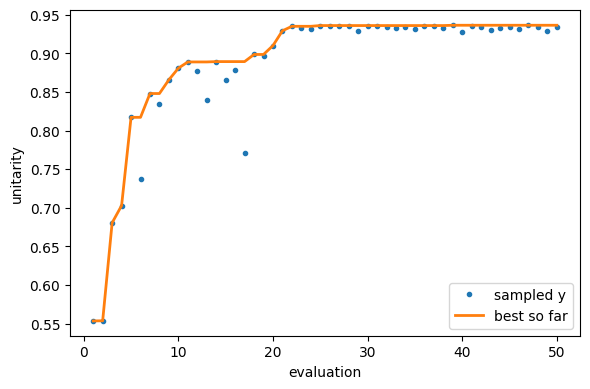

In [6]:
x_hist = result1["x_history"].detach().cpu()
y_hist = result1["y_history"][:, 0].detach().cpu()
best_so_far = torch.cummax(y_hist, dim=0).values
evals = torch.arange(1, len(y_hist) + 1)

plt.figure(figsize=PAPER_FIGSIZE)
plt.plot(evals, y_hist, ".", label="sampled y")
plt.plot(evals, best_so_far, linewidth=2, label="best so far")
plt.xlabel("evaluation")
plt.ylabel("unitarity")
plt.legend()
plt.tight_layout()
plt.show()


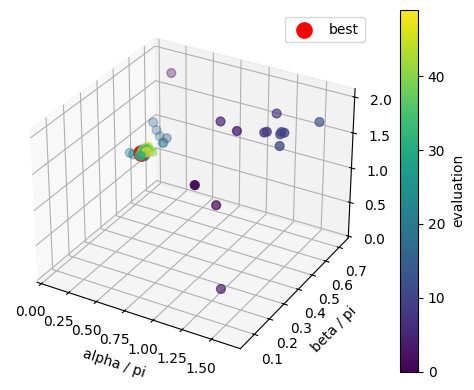

In [7]:
def normalized_angles_to_pi_units(x):
    """
    Convert normalized angles:
        [alpha / (2*pi), beta / pi, gamma / (2*pi)]
    to pi units:
        [alpha / pi, beta / pi, gamma / pi]
    """
    x = torch.as_tensor(x).detach().cpu()
    return torch.stack([2 * x[..., 0], x[..., 1], 2 * x[..., 2]], dim=-1)

x = result1["x_history"][:, ...].detach().cpu()
y = result1["y_history"][:, 0].detach().cpu()

angles_pi = normalized_angles_to_pi_units(x)

fig = plt.figure(figsize=PAPER_FIGSIZE)
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    angles_pi[:, 0],
    angles_pi[:, 1],
    angles_pi[:, 2],
    c=torch.arange(len(y)),
    cmap="viridis",
    s=40,
)

best_idx = y.argmax()
ax.scatter(
    angles_pi[best_idx, 0],
    angles_pi[best_idx, 1],
    angles_pi[best_idx, 2],
    color="red",
    s=120,
    label="best",
)

ax.set_xlabel("alpha / pi")
ax.set_ylabel("beta / pi")
ax.set_zlabel("gamma / pi")
fig.colorbar(sc, ax=ax, label="evaluation")
ax.legend()
plt.tight_layout()
plt.show()


loaded: jobs/unitarity3d/unitarity3d_resume_153135_20260528_145042/model_weights.pt
step: None seen_train_datasets: None
parameters: None


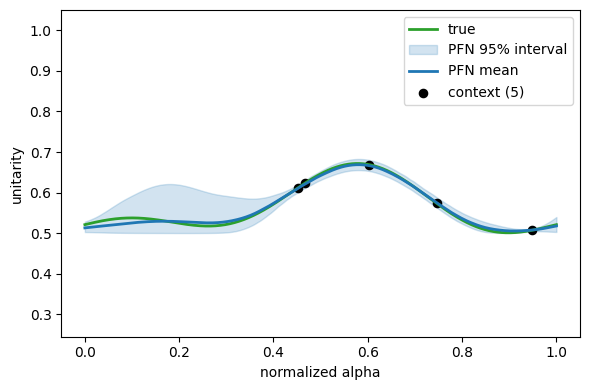

In [8]:
fig, ax, unitarity3d = plot_unitarity3d_prediction(checkpoint_path=CHECKPOINT2,
                                                           context_points=5,
                                                           vary_angle="alpha",
                                                           seed=SEED,
                                                           r_dec=r_dec,
                                                           d_env=d_env
)
plt.show()

In [9]:
result2 = run_ei_search_unitarity3d(
    checkpoint_path=CHECKPOINT2,
    budget=BUDGET,
    initial_points=1,
    candidate_points=20000,
    xi=0.0,
    seed=SEED,
    r_dec=r_dec,
    d_env=d_env
)

result2["best_x"], result2["best_y"]


 10/50: best y = 0.936334, LogEI = -7.2881
 20/50: best y = 0.936334, LogEI = -6.25321
 30/50: best y = 0.936334, LogEI = -6.38139
 40/50: best y = 0.936366, LogEI = -6.3545
 50/50: best y = 0.936366, LogEI = -6.56106


(tensor([0.0797, 0.5431, 0.4745], device='cuda:0'),
 tensor(0.9364, device='cuda:0'))

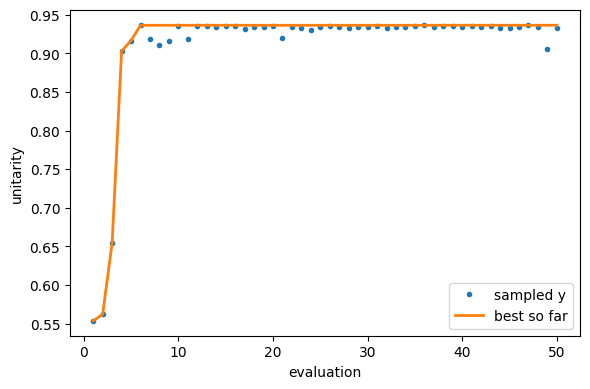

In [10]:
x_hist = result2["x_history"].detach().cpu()
y_hist = result2["y_history"][:, 0].detach().cpu()
best_so_far = torch.cummax(y_hist, dim=0).values
evals = torch.arange(1, len(y_hist) + 1)

plt.figure(figsize=PAPER_FIGSIZE)
plt.plot(evals, y_hist, ".", label="sampled y")
plt.plot(evals, best_so_far, linewidth=2, label="best so far")
plt.xlabel("evaluation")
plt.ylabel("unitarity")
plt.legend()
plt.tight_layout()
plt.show()


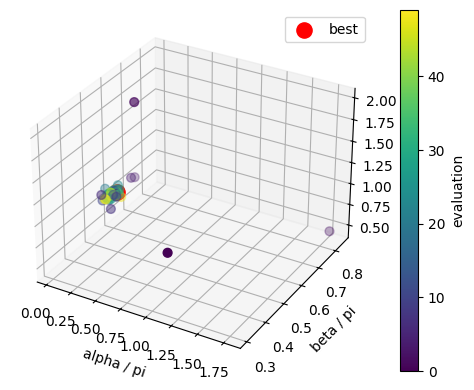

In [11]:
x = result2["x_history"][:, ...].detach().cpu()
y = result2["y_history"][:, 0].detach().cpu()

angles_pi = normalized_angles_to_pi_units(x)

fig = plt.figure(figsize=PAPER_FIGSIZE)
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    angles_pi[:, 0],
    angles_pi[:, 1],
    angles_pi[:, 2],
    c=torch.arange(len(y)),
    cmap="viridis",
    s=40,
)

best_idx = y.argmax()
ax.scatter(
    angles_pi[best_idx, 0],
    angles_pi[best_idx, 1],
    angles_pi[best_idx, 2],
    color="red",
    s=120,
    label="best",
)

ax.set_xlabel("alpha / pi")
ax.set_ylabel("beta / pi")
ax.set_zlabel("gamma / pi")
fig.colorbar(sc, ax=ax, label="evaluation")
ax.legend()
plt.tight_layout()
plt.show()


In [12]:
import gpytorch
from botorch.acquisition import LogExpectedImprovement
from botorch.fit import fit_gpytorch_mll
from botorch.models import SingleTaskGP
from botorch.models.transforms import Standardize

def run_gp_ei_search_unitarity3d(
    seed,
    r_dec=2,
    d_env=2,
    budget=80,
    initial_points=5,
    candidate_points=20000,
):

    if not (1 <= initial_points <= budget):
        raise ValueError("initial_points must be in [1, budget].")

    torch.manual_seed(seed)
    if DEVICE.type == "cuda":
        torch.cuda.manual_seed_all(seed)

    comb = kraus.generate_one_slot_kraus_comb(
        num_samples=1,
        sys_dim=(2, 2, 2, 2),
        env_dim=d_env,
        r_enc=1,
        r_dec=r_dec,
    ).to(DEVICE)

    x_hist = sample_haar_normalized_x(initial_points, DEVICE)
    y_hist = evaluate_unitarity3d_x(x_hist, comb).reshape(initial_points, 1)
    for step in range(initial_points, budget):
        gp = SingleTaskGP(x_hist, y_hist, outcome_transform=Standardize(m=1))
        mll = gpytorch.mlls.ExactMarginalLogLikelihood(gp.likelihood, gp)
        fit_gpytorch_mll(mll)

        ei = LogExpectedImprovement(gp, best_f=y_hist.max().item())
        x_candidates = sample_haar_normalized_x(candidate_points, DEVICE)
        acq_values = ei(x_candidates.unsqueeze(1))
        next_x = x_candidates[acq_values.argmax()].detach()
        next_y = evaluate_unitarity3d_x(next_x.reshape(1, 3), comb).reshape(1, 1)
        x_hist = torch.cat([x_hist, next_x.reshape(1, 3)], dim=0)
        y_hist = torch.cat([y_hist, next_y], dim=0)

        if (step + 1) % 10 == 0 or step + 1 == budget:
            print(f"{step + 1:3d}/{budget}: GP+EI best y = {y_hist.max().item():.6f}")

    best_idx = y_hist[:, 0].argmax()
    return {
        "best_x": x_hist[best_idx],
        "best_y": y_hist[best_idx, 0],
        "x_history": x_hist,
        "y_history": y_hist,
        "comb": comb,
    }

/mnt/iusers01/fatpou01/compsci01/a49626th/Quantum_ML/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
gp_result = run_gp_ei_search_unitarity3d(
    seed=SEED,
    budget=BUDGET+100,
    initial_points=5,
    r_dec=r_dec,
    d_env=d_env
)
gp_result["best_x"], gp_result["best_y"]


 10/150: GP+EI best y = 0.845992
 20/150: GP+EI best y = 0.908070
 30/150: GP+EI best y = 0.910219
 40/150: GP+EI best y = 0.910219
 50/150: GP+EI best y = 0.934952
 60/150: GP+EI best y = 0.936252
 70/150: GP+EI best y = 0.936368
 80/150: GP+EI best y = 0.936368
 90/150: GP+EI best y = 0.936368
100/150: GP+EI best y = 0.936368
110/150: GP+EI best y = 0.936368
120/150: GP+EI best y = 0.936368
130/150: GP+EI best y = 0.936368
140/150: GP+EI best y = 0.936368
150/150: GP+EI best y = 0.936368


(tensor([0.0830, 0.5358, 0.4727], device='cuda:0'),
 tensor(0.9364, device='cuda:0'))

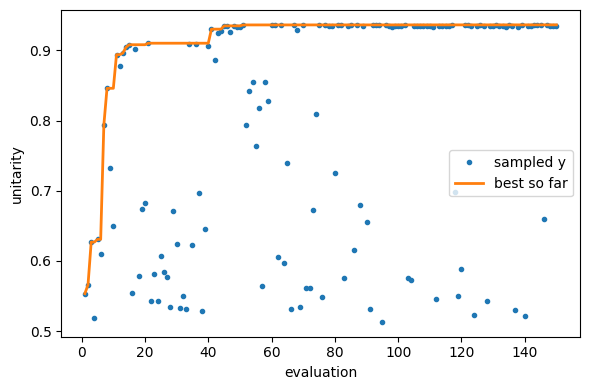

In [14]:
x_hist = gp_result["x_history"].detach().cpu()
y_hist = gp_result["y_history"][:, 0].detach().cpu()
best_so_far = torch.cummax(y_hist, dim=0).values
evals = torch.arange(1, len(y_hist) + 1)

plt.figure(figsize=PAPER_FIGSIZE)
plt.plot(evals, y_hist, ".", label="sampled y")
plt.plot(evals, best_so_far, linewidth=2, label="best so far")
plt.xlabel("evaluation")
plt.ylabel("unitarity")
plt.legend()
plt.tight_layout()
plt.show()


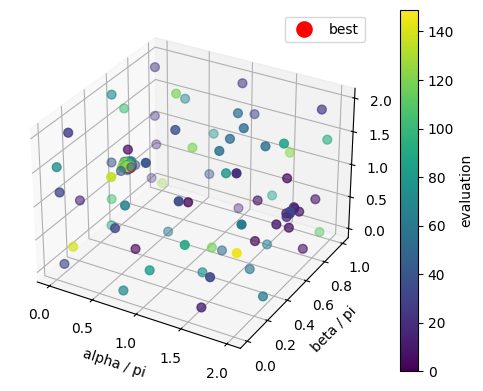

In [15]:
x = gp_result["x_history"][:, ...].detach().cpu()
y = gp_result["y_history"][:, 0].detach().cpu()

angles_pi = normalized_angles_to_pi_units(x)

fig = plt.figure(figsize=PAPER_FIGSIZE)
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    angles_pi[:, 0],
    angles_pi[:, 1],
    angles_pi[:, 2],
    c=torch.arange(len(y)),
    cmap="viridis",
    s=40,
)

best_idx = y.argmax()
ax.scatter(
    angles_pi[best_idx, 0],
    angles_pi[best_idx, 1],
    angles_pi[best_idx, 2],
    color="red",
    s=120,
    label="best",
)

ax.set_xlabel("alpha / pi")
ax.set_ylabel("beta / pi")
ax.set_zlabel("gamma / pi")
fig.colorbar(sc, ax=ax, label="evaluation")
ax.legend()
plt.tight_layout()
plt.show()


In [16]:
@torch.no_grad()
def run_random_haar_search_unitarity3d(
    seed,
    budget=50,
    d_env=2,
    r_dec=2,
):
    torch.manual_seed(seed)
    if DEVICE.type == "cuda":
        torch.cuda.manual_seed_all(seed)

    comb = kraus.generate_one_slot_kraus_comb(
        num_samples=1,
        sys_dim=(2, 2, 2, 2),
        env_dim=d_env,
        r_enc=1,
        r_dec=r_dec,
    ).to(DEVICE)

    x_hist = sample_haar_normalized_x(budget, DEVICE)
    y_chunks = []
    best_so_far = -float("inf")
    print_every = 10

    for start in range(0, budget, print_every):
        end = min(start + print_every, budget)
        y_chunk = evaluate_unitarity3d_x(x_hist[start:end], comb).reshape(end - start, 1)
        y_chunks.append(y_chunk)
        best_so_far = max(best_so_far, y_chunk.max().item())

        if end % print_every == 0 or end == budget:
            print(f"{end:3d}/{budget}: random Haar best y = {best_so_far:.6f}")

    y_hist = torch.cat(y_chunks, dim=0)

    best_idx = y_hist[:, 0].argmax()

    return {
        "best_x": x_hist[best_idx],
        "best_y": y_hist[best_idx, 0],
        "x_history": x_hist,
        "y_history": y_hist,
        "comb": comb,
    }

In [17]:
random_result = run_random_haar_search_unitarity3d(SEED, 1000)
random_result["best_x"], random_result["best_y"]

 10/1000: random Haar best y = 0.724257
 20/1000: random Haar best y = 0.802769
 30/1000: random Haar best y = 0.802769
 40/1000: random Haar best y = 0.802769
 50/1000: random Haar best y = 0.802769
 60/1000: random Haar best y = 0.802769
 70/1000: random Haar best y = 0.861006
 80/1000: random Haar best y = 0.876474
 90/1000: random Haar best y = 0.876474
100/1000: random Haar best y = 0.876474
110/1000: random Haar best y = 0.905205
120/1000: random Haar best y = 0.905205
130/1000: random Haar best y = 0.905205
140/1000: random Haar best y = 0.905205
150/1000: random Haar best y = 0.905205
160/1000: random Haar best y = 0.905205
170/1000: random Haar best y = 0.905205
180/1000: random Haar best y = 0.905205
190/1000: random Haar best y = 0.905205
200/1000: random Haar best y = 0.905205
210/1000: random Haar best y = 0.905205
220/1000: random Haar best y = 0.905205
230/1000: random Haar best y = 0.905205
240/1000: random Haar best y = 0.905205
250/1000: random Haar best y = 0.905205


(tensor([0.0996, 0.4953, 0.4997], device='cuda:0'),
 tensor(0.9225, device='cuda:0'))

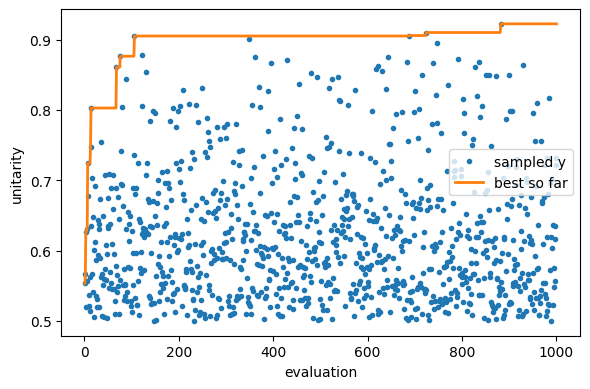

In [18]:
x_hist = random_result["x_history"].detach().cpu()
y_hist = random_result["y_history"][:, 0].detach().cpu()
best_so_far = torch.cummax(y_hist, dim=0).values
evals = torch.arange(1, len(y_hist) + 1)

plt.figure(figsize=PAPER_FIGSIZE)
plt.plot(evals, y_hist, ".", label="sampled y")
plt.plot(evals, best_so_far, linewidth=2, label="best so far")
plt.xlabel("evaluation")
plt.ylabel("unitarity")
plt.legend()
plt.tight_layout()
plt.show()


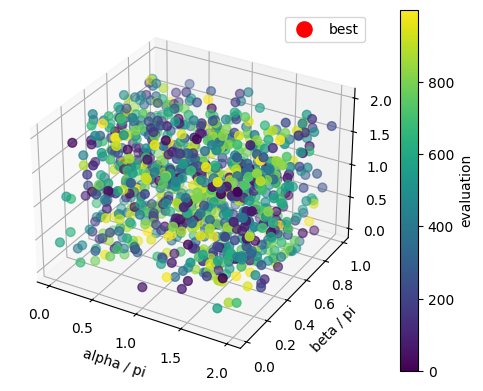

In [19]:
x = random_result["x_history"][:, ...].detach().cpu()
y = random_result["y_history"][:, 0].detach().cpu()

angles_pi = normalized_angles_to_pi_units(x)

fig = plt.figure(figsize=PAPER_FIGSIZE)
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    angles_pi[:, 0],
    angles_pi[:, 1],
    angles_pi[:, 2],
    c=torch.arange(len(y)),
    cmap="viridis",
    s=40,
)

best_idx = y.argmax()
ax.scatter(
    angles_pi[best_idx, 0],
    angles_pi[best_idx, 1],
    angles_pi[best_idx, 2],
    color="red",
    s=120,
    label="best",
)

ax.set_xlabel("alpha / pi")
ax.set_ylabel("beta / pi")
ax.set_zlabel("gamma / pi")
fig.colorbar(sc, ax=ax, label="evaluation")
ax.legend()
plt.tight_layout()
plt.show()


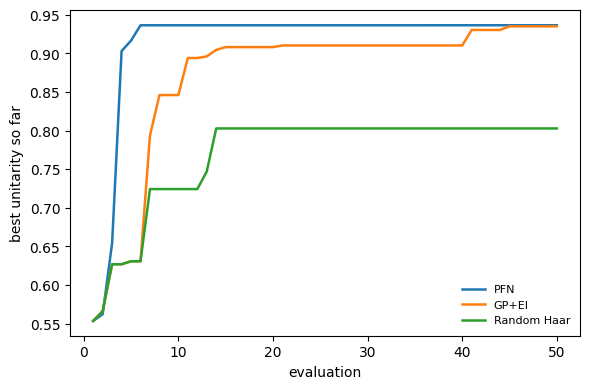

In [20]:
fig, ax = plot_best_so_far_comparison(
    [
        ("PFN", result2),
        ("GP+EI", gp_result),
        ("Random Haar", random_result),
    ],
    max_evals=BUDGET,
)
plt.show()


In [21]:
CHECKPOINT3 = Path(
    "jobs/unitarity3d/unitarity3d_rdec4_30m_resume_20260604_155933/model_weights.pt"
)

r_dec = 4
d_env = 2

loaded: jobs/unitarity3d/unitarity3d_rdec4_30m_resume_20260604_155933/model_weights.pt
step: None seen_train_datasets: None
parameters: None


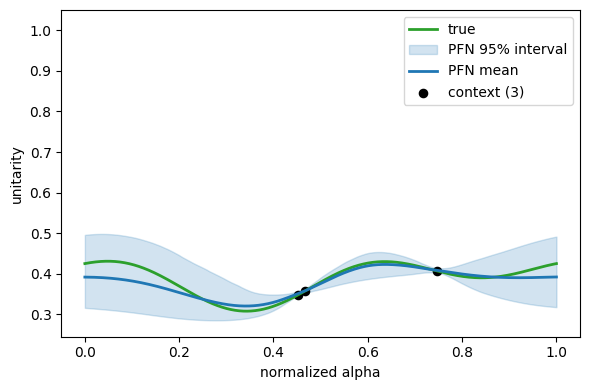

In [22]:
fig, ax, unitarity3d = plot_unitarity3d_prediction(checkpoint_path=CHECKPOINT3,
                                                           context_points=3,
                                                           vary_angle="alpha",
                                                           seed=SEED,
                                                           r_dec=r_dec,
                                                           d_env=d_env
)
plt.show()

In [23]:
result = run_ei_search_unitarity3d(
    checkpoint_path=CHECKPOINT3,
    budget=BUDGET,
    initial_points=1,
    candidate_points=20000,
    xi=0.0,
    seed=SEED,
    r_dec=r_dec,
    d_env=d_env,
)

result["best_x"], result["best_y"]


 10/50: best y = 0.587834, LogEI = -4.36808
 20/50: best y = 0.599801, LogEI = -7.15839
 30/50: best y = 0.599821, LogEI = -7.50114
 40/50: best y = 0.599821, LogEI = -7.63045
 50/50: best y = 0.599821, LogEI = -7.75884


(tensor([0.6397, 0.4519, 0.9464], device='cuda:0'),
 tensor(0.5998, device='cuda:0'))

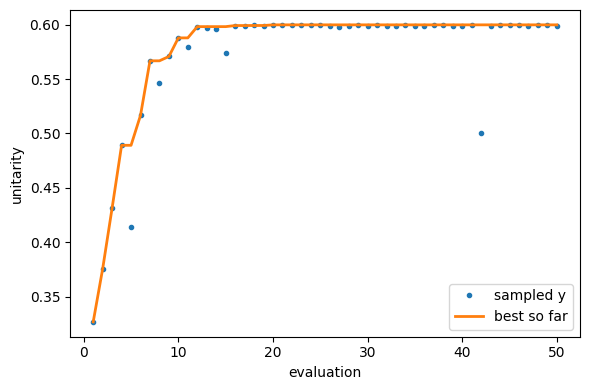

In [24]:
x_hist = result["x_history"].detach().cpu()
y_hist = result["y_history"][:, 0].detach().cpu()
best_so_far = torch.cummax(y_hist, dim=0).values
evals = torch.arange(1, len(y_hist) + 1)

plt.figure(figsize=PAPER_FIGSIZE)
plt.plot(evals, y_hist, ".", label="sampled y")
plt.plot(evals, best_so_far, linewidth=2, label="best so far")
plt.xlabel("evaluation")
plt.ylabel("unitarity")
plt.legend()
plt.tight_layout()
plt.show()


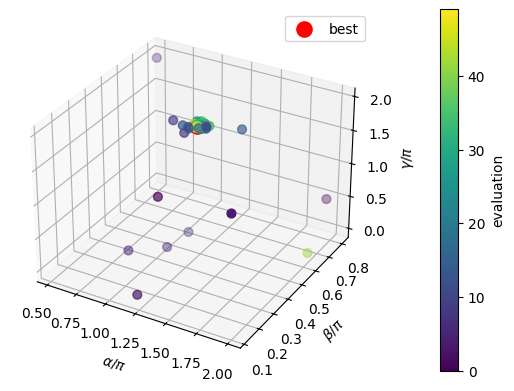

In [25]:
x = result["x_history"][:, ...].detach().cpu()
y = result["y_history"][:, 0].detach().cpu()

angles_pi = normalized_angles_to_pi_units(x)

fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    angles_pi[:, 0],
    angles_pi[:, 1],
    angles_pi[:, 2],
    c=torch.arange(len(y)),
    cmap="viridis",
    s=40,
)

best_idx = y.argmax()
ax.scatter(
    angles_pi[best_idx, 0],
    angles_pi[best_idx, 1],
    angles_pi[best_idx, 2],
    color="red",
    s=120,
    label="best",
)

ax.set_xlabel(r"$\alpha / \pi$")
ax.set_ylabel(r"$\beta / \pi$")
ax.set_zlabel(r"$\gamma / \pi$")

cbar = fig.colorbar(sc, ax=ax, label=r"evaluation", pad=0.12)

ax.legend()
plt.tight_layout()
plt.show()



In [26]:
gp_result = run_gp_ei_search_unitarity3d(
    seed=SEED,
    budget=BUDGET+100,
    initial_points=5,
    r_dec=r_dec,
    d_env=d_env,
)
gp_result["best_x"], gp_result["best_y"]


 10/150: GP+EI best y = 0.463183
 20/150: GP+EI best y = 0.514174
 30/150: GP+EI best y = 0.599841
 40/150: GP+EI best y = 0.599841
 50/150: GP+EI best y = 0.599841
 60/150: GP+EI best y = 0.599841
 70/150: GP+EI best y = 0.599841
 80/150: GP+EI best y = 0.599841
 90/150: GP+EI best y = 0.599841
100/150: GP+EI best y = 0.599996
110/150: GP+EI best y = 0.599996
120/150: GP+EI best y = 0.599996
130/150: GP+EI best y = 0.599996
140/150: GP+EI best y = 0.599996
150/150: GP+EI best y = 0.599996


(tensor([0.6438, 0.4611, 0.9483], device='cuda:0'),
 tensor(0.6000, device='cuda:0'))

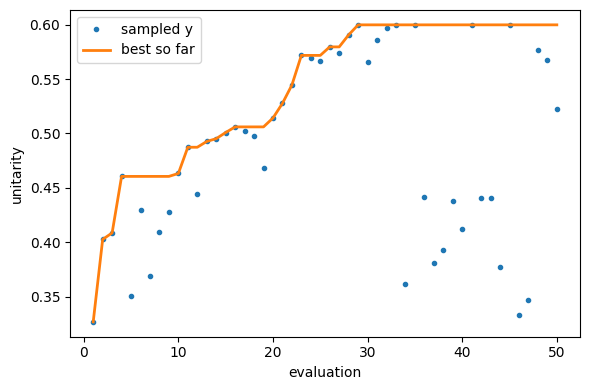

In [27]:
x_hist = gp_result["x_history"][:50, ...].detach().cpu()
y_hist = gp_result["y_history"][:50, 0].detach().cpu()
best_so_far = torch.cummax(y_hist, dim=0).values
evals = torch.arange(1, len(y_hist) + 1)

plt.figure(figsize=PAPER_FIGSIZE)
plt.plot(evals, y_hist, ".", label="sampled y")
plt.plot(evals, best_so_far, linewidth=2, label="best so far")
plt.xlabel("evaluation")
plt.ylabel("unitarity")
plt.legend()
plt.tight_layout()
plt.show()


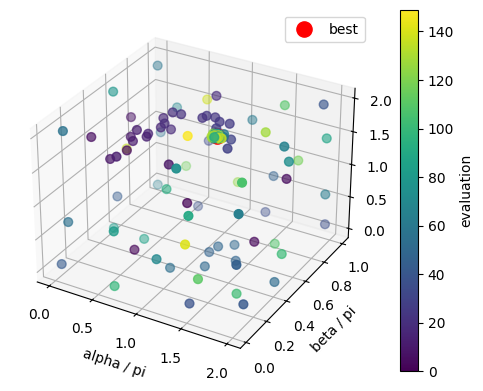

In [28]:
x = gp_result["x_history"][:, ...].detach().cpu()
y = gp_result["y_history"][:, 0].detach().cpu()

angles_pi = normalized_angles_to_pi_units(x)

fig = plt.figure(figsize=PAPER_FIGSIZE)
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    angles_pi[:, 0],
    angles_pi[:, 1],
    angles_pi[:, 2],
    c=torch.arange(len(y)),
    cmap="viridis",
    s=40,
)

best_idx = y.argmax()
ax.scatter(
    angles_pi[best_idx, 0],
    angles_pi[best_idx, 1],
    angles_pi[best_idx, 2],
    color="red",
    s=120,
    label="best",
)

ax.set_xlabel("alpha / pi")
ax.set_ylabel("beta / pi")
ax.set_zlabel("gamma / pi")
fig.colorbar(sc, ax=ax, label="evaluation")
ax.legend()
plt.tight_layout()
plt.show()


In [29]:
random_result = run_random_haar_search_unitarity3d(SEED, 1000, d_env=d_env, r_dec=r_dec)
random_result["best_x"], random_result["best_y"]

 10/1000: random Haar best y = 0.460471
 20/1000: random Haar best y = 0.580010
 30/1000: random Haar best y = 0.580010
 40/1000: random Haar best y = 0.580010
 50/1000: random Haar best y = 0.580010
 60/1000: random Haar best y = 0.580010
 70/1000: random Haar best y = 0.580010
 80/1000: random Haar best y = 0.580010
 90/1000: random Haar best y = 0.580010
100/1000: random Haar best y = 0.580010
110/1000: random Haar best y = 0.580010
120/1000: random Haar best y = 0.580010
130/1000: random Haar best y = 0.580010
140/1000: random Haar best y = 0.580010
150/1000: random Haar best y = 0.580010
160/1000: random Haar best y = 0.580010
170/1000: random Haar best y = 0.580010
180/1000: random Haar best y = 0.580010
190/1000: random Haar best y = 0.580010
200/1000: random Haar best y = 0.580010
210/1000: random Haar best y = 0.580010
220/1000: random Haar best y = 0.580010
230/1000: random Haar best y = 0.580010
240/1000: random Haar best y = 0.580010
250/1000: random Haar best y = 0.580010


(tensor([0.6504, 0.4492, 0.9629], device='cuda:0'),
 tensor(0.5981, device='cuda:0'))

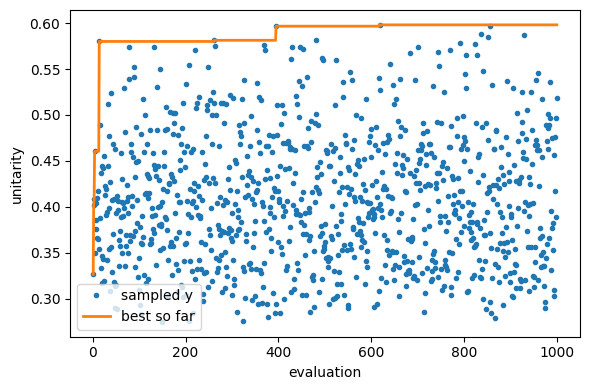

In [30]:
x_hist = random_result["x_history"].detach().cpu()
y_hist = random_result["y_history"][:, 0].detach().cpu()
best_so_far = torch.cummax(y_hist, dim=0).values
evals = torch.arange(1, len(y_hist) + 1)

plt.figure(figsize=PAPER_FIGSIZE)
plt.plot(evals, y_hist, ".", label="sampled y")
plt.plot(evals, best_so_far, linewidth=2, label="best so far")
plt.xlabel("evaluation")
plt.ylabel("unitarity")
plt.legend()
plt.tight_layout()
plt.show()


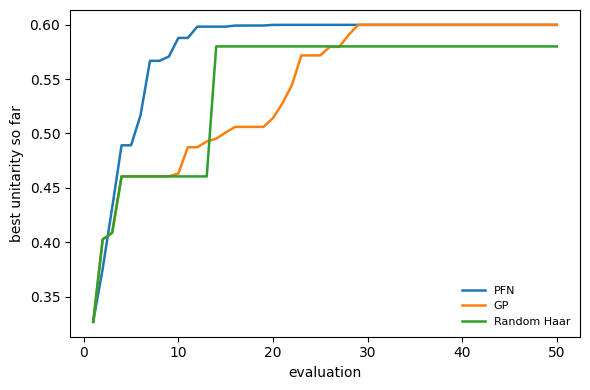

In [31]:
fig, ax = plot_best_so_far_comparison(
    [
        ("PFN", result),
        ("GP", gp_result),
        ("Random Haar", random_result),
    ],
    max_evals=BUDGET,
)
plt.show()
